In [20]:
import numpy as np

def generate_mixed_positions(
    N,
    L,
    frac_agg,
    n_centers,
    base_sigma,
    rng,
    sigma_mode="same",
    sigma_min=0.05,
    sigma_max=0.20
):
    """
    Genera posiciones en un dominio cuadrado L x L.

    sigma_mode:
        "same"   -> todos los centros tienen sigma = base_sigma
        "random" -> cada centro tiene una sigma aleatoria entre sigma_min y sigma_max
    """

    N_agg = int(frac_agg * N)
    N_rand = N - N_agg

    # ============================================================
    # Centros de agregación
    # ============================================================

    centers = rng.uniform(
        low=-L/2,
        high=L/2,
        size=(n_centers, 2)
    )

    # ============================================================
    # Sigma de cada centro
    # ============================================================

    if sigma_mode == "same":
        sigmas = np.full(n_centers, base_sigma)

    elif sigma_mode == "random":
        sigmas = rng.uniform(
            low=sigma_min,
            high=sigma_max,
            size=n_centers
        )

    else:
        raise ValueError("sigma_mode debe ser 'same' o 'random'")

    # ============================================================
    # Neuronas agregadas
    # ============================================================

    positions_agg = []

    for i in range(N_agg):
        # Elegimos un centro al azar
        c_idx = rng.integers(0, n_centers)

        center = centers[c_idx]
        sigma = sigmas[c_idx]

        # Generamos una neurona alrededor de ese centro
        pos = rng.normal(
            loc=center,
            scale=sigma,
            size=2
        )

        # Si cae fuera del dominio, la reintentamos
        while (
            pos[0] < -L/2 or pos[0] > L/2 or
            pos[1] < -L/2 or pos[1] > L/2
        ):
            pos = rng.normal(
                loc=center,
                scale=sigma,
                size=2
            )

        positions_agg.append(pos)

    positions_agg = np.array(positions_agg)

    # ============================================================
    # Neuronas random
    # ============================================================

    positions_rand = rng.uniform(
        low=-L/2,
        high=L/2,
        size=(N_rand, 2)
    )

    # ============================================================
    # Juntar posiciones
    # ============================================================

    positions = np.vstack([positions_agg, positions_rand])

    labels = np.array(["agg"] * N_agg + ["rand"] * N_rand)

    return positions, centers, labels, sigmas



def create_distance_network(
    positions,
    r_conn,
    alpha=0.2,
    directed=False,
    rng=None
):
    """
    Crea una matriz de adyacencia A.

    Si la distancia entre dos neuronas es menor que r_conn,
    se conectan con probabilidad alpha.

    directed=False crea una red no dirigida.
    directed=True crea una red dirigida.
    """

    if rng is None:
        rng = np.random.default_rng()

    N = positions.shape[0]
    A = np.zeros((N, N), dtype=int)

    if directed:

        for i in range(N):
            for j in range(N):

                if i == j:
                    continue

                dist = np.linalg.norm(positions[i] - positions[j])

                if dist <= r_conn:
                    if rng.random() < alpha:
                        A[i, j] = 1

    else:

        for i in range(N):
            for j in range(i + 1, N):

                dist = np.linalg.norm(positions[i] - positions[j])

                if dist <= r_conn:
                    if rng.random() < alpha:
                        A[i, j] = 1
                        A[j, i] = 1

    return A

def Gini(X,Y, L, n_grid):

    H, x_edges, y_edges = np.histogram2d(
        X, Y,
        bins=n_grid,
        range=[[-L/2, L/2], [-L/2, L/2]]
    )

    H_flat = H.flatten()
    H_flat = np.sort(H_flat)[::-1]

    G = np.zeros(len(H_flat))
    sum_gini = 0.0

    for i, h in enumerate(H_flat):
        sum_gini += h
        G[i] = sum_gini / H.sum()

    bins = np.arange(1, len(H_flat) + 1)
    bins = bins / len(H_flat)

    area_between = np.trapezoid(G - bins, bins)
    Gini = 2 * area_between

    H_plot = H.T  # Transponer para que el eje x corresponda a X y el eje y a Y

    return Gini, H_plot, x_edges, y_edges

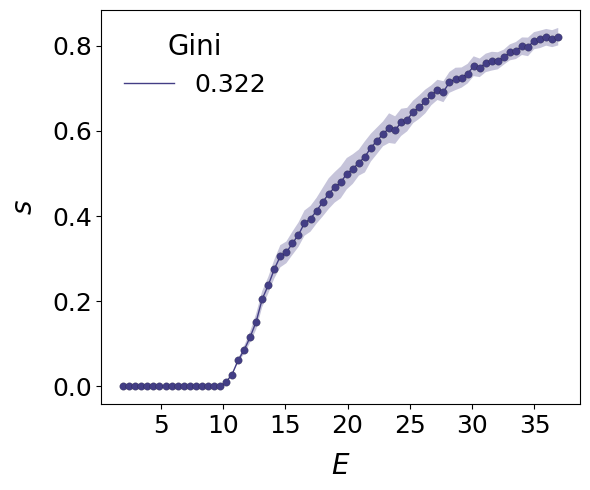

In [21]:
# ============================================================
# Plot: sincronización frente a excitación
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pypalettes import load_cmap
base_sigma = 0.50
output_file = f"Sync_VS_ExcitatioN_{base_sigma:.2f}_MEAN.csv"
df_results = pd.read_csv(output_file)
gini_value = (
    float(df_results["Gini"].dropna().iloc[0])
    if "Gini" in df_results.columns and not df_results["Gini"].dropna().empty
    else np.nan
)
gini_text = f"{gini_value:.3f}" if np.isfinite(gini_value) else "NaN"

viridis = load_cmap("viridis")

plt.figure(figsize=(6, 5))

plt.plot(
    df_results["MAX_EXC_WEIGHT"],
    df_results["mean_peak_height_weighted"],
    color=viridis(0.1),
    label=gini_text, 
    lw = 1
)

plt.scatter(
    df_results["MAX_EXC_WEIGHT"],
    df_results["mean_peak_height_weighted"],
    color=viridis(0.1),
    edgecolor="black",
    linewidth=0.1,
    s=30,
    zorder=3
)

plt.fill_between(
    df_results["MAX_EXC_WEIGHT"],
    df_results["mean_peak_height_weighted"] - df_results["error_mean_peak_height_weighted"],
    df_results["mean_peak_height_weighted"] + df_results["error_mean_peak_height_weighted"],
    color=viridis(0.1),
    alpha=0.3, 
    edgecolor="none"
)


plt.xlabel(r"$E$", fontsize = 20, labelpad = 10)
plt.ylabel(r"$s$", fontsize = 20, labelpad = 10)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
# plt.title(f"Synchronisation vs excitation | Gini = {Gini:.3f}")
plt.legend(title="Gini", fontsize=18, title_fontsize=20, frameon = False)



# plt.text(
#     0.75, 0.1,
#     rf"$\Lambda = {gini_text}$",
#     ha="center", va="center",
#     transform=plt.gca().transAxes,
#     fontsize=20
# )
# plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [22]:
# Poner neuronas en un plano de LxL
## Poner un 70% agragadas y el otro 30% random
## La agregación la hacemos poniendo unos centros de menra aleatoria en la red con una cierta anchura y 
## colocando las neuronas en esos centros, el resto random en el espacio.
# Generar conexiones de acuerdo a la distancia entre neuronas con una cierta probabilidad de conexión.

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from pypalettes import load_cmap

viridis = load_cmap("viridis")


# ============================================================
# Parámetros principales
# ============================================================

L = 1.5              # Tamaño del dominio L x L, en mm
N = 1000          # Número total de neuronas
Neuron_per_center = 250
frac_agg = 0.001 # Fracción de neuronas agregadas
n_centers = N // Neuron_per_center  # Número de centros de agregación
base_sigma = 0.50    # Anchura de los agregados, en mm

r_conn = 0.05   # Radio de conexión, en mm
alpha = 0.5       # Probabilidad de conexión si están dentro del radio

seed = np.random.SeedSequence().entropy
rng = np.random.default_rng(seed)


# ============================================================
# Generar posiciones: 70% agregadas + 30% random
# ============================================================

positions, centers, labels, sigmas = generate_mixed_positions(
    N=N,
    L=L,
    frac_agg=frac_agg,
    n_centers=n_centers,
    base_sigma=base_sigma,
    rng=rng,
    sigma_mode="same",   # "same" o "random"
    sigma_min=0.05,
    sigma_max=0.20
)

# ============================================================
# Crear matriz de adyacencia según distancia y probabilidad alpha
# ============================================================

A = create_distance_network(
    positions=positions,
    r_conn=r_conn,
    alpha=alpha,
    directed=False,
    rng=rng
)

# ============================================================
# Convertir a grafo de NetworkX
# ============================================================
# ============================================================
# Convertir a grafo de NetworkX y quedarse con la componente gigante
# ============================================================

# ============================================================
# Convertir a grafo de NetworkX y detectar componente gigante
# ============================================================

A_full = A.copy()
positions_full = positions.copy()
labels_full = labels.copy()
N_full = N

G_full = nx.from_numpy_array(A_full)

print("Número de neuronas inicial:", N_full)
print("Número de enlaces inicial:", G_full.number_of_edges())
print("Grado medio inicial:", np.mean([d for _, d in G_full.degree()]))
print("Densidad inicial:", nx.density(G_full))

if nx.is_connected(G_full):
    print("La red inicial es conexa")
    GC_nodes = np.arange(N_full)

else:
    GC = max(nx.connected_components(G_full), key=len)
    GC_nodes = np.array(sorted(list(GC)))

    print("La red inicial no es conexa")
    print("Tamaño de la componente gigante:", len(GC_nodes))
    print("Fracción en componente gigante:", len(GC_nodes) / N_full)

# Máscara booleana para saber qué nodos pertenecen a la CG
is_GC = np.zeros(N_full, dtype=bool)
is_GC[GC_nodes] = True

# ============================================================
# Reducir A, positions, labels y N a la componente gigante
# para TODO lo que venga después: Louvain, dinámica, etc.
# ============================================================

A = A_full[np.ix_(GC_nodes, GC_nodes)] # This is the adjacency matrix of the giant component
np.save("A_GC.npy", A)
positions = positions_full[GC_nodes]
np.save("positions_GC.npy", positions)
labels = labels_full[GC_nodes]

N_original = N_full
N = A.shape[0]

G = nx.from_numpy_array(A)

print("\nDespués de quedarnos con la componente gigante:")
print("Número de neuronas:", N)
print("Número de enlaces:", G.number_of_edges())
print("Grado medio:", np.mean([d for _, d in G.degree()]))
print("Densidad:", nx.density(G))
print("¿Es conexa ahora?:", nx.is_connected(G))

# ============================================================
# Ordenar matriz de adyacencia por comunidades
# ============================================================

# Grafo completo, no solo la componente gigante
G_for_plot = nx.from_numpy_array(A_full)

# Detectar comunidades en toda la red
communities_full = nx.community.louvain_communities(G_for_plot, seed=seed)

# Ordenar comunidades por tamaño, de mayor a menor
communities_full = sorted(communities_full, key=len, reverse=True)

# Lista de nodos ordenados por comunidad
ordered_nodes_full = []
community_boundaries_full = []

count = 0
for comm in communities_full:
    comm_sorted = sorted(list(comm))
    ordered_nodes_full.extend(comm_sorted)

    count += len(comm_sorted)
    community_boundaries_full.append(count)

# Reordenar la matriz completa
A_full_ordered = A_full[np.ix_(ordered_nodes_full, ordered_nodes_full)]

print("Número de comunidades detectadas en la red completa:", len(communities_full))
print("Tamaños de comunidades red completa:", [len(c) for c in communities_full])


# ============================================================
# Plot conjunto: posiciones + matriz de adyacencia ordenada
# ============================================================

plt.figure(figsize=(6, 5.3))

# ============================================================
# Izquierda: distribución espacial
# ============================================================

# ============================================================
# Izquierda: distribución espacial completa
# ============================================================



# Primero ploteamos los nodos que NO están en la CG
plt.scatter(
    positions_full[~is_GC, 0],
    positions_full[~is_GC, 1],
    s=10,
    alpha=1,
    color=viridis(0.1),
    label="Out GC",
    edgecolors='none'
)

n_grid = 21
Gini_coeff, H_plot, x_edges, y_edges = Gini(
    X=positions_full[:, 0],
    Y=positions_full[:, 1],
    L=L,
    n_grid=n_grid
)

xmin = -L/2
xmax = L/2
ymin = -L/2
ymax = L/2

x_grid = np.linspace(xmin, xmax, n_grid + 1)
y_grid = np.linspace(ymin, ymax, n_grid + 1)

# for x in x_grid:
#     ax.axvline(x, color='black', lw=0.3, alpha=0.4)

# for y in y_grid:
#     ax.axhline(y, color='black', lw=0.3, alpha=0.4)

# ax.imshow(
#     H_plot,
#     extent=[xmin, xmax, ymin, ymax],
#     origin='lower',
#     cmap='Reds',
#     alpha=0.5
# )

# plt.text(
#     0.5, -0.6,
#     f"Gini: {Gini_coeff:.2f}",
#     fontsize=14,
#     color='black',
#     ha='center',
#     va='center',
#     bbox=dict(facecolor='white', alpha=1, edgecolor='none')
# )

# SHow a grid using n_grid 

# Después ploteamos encima los nodos de la CG
plt.scatter(
    positions_full[is_GC, 0],
    positions_full[is_GC, 1],
    s=10,
    alpha=1,
    color=viridis(0.1),
    label="GC", 
    edgecolors='black', 
    linewidths=0.1
)
plt.xticks([-0.8, -0.4, 0, 0.4, 0.8], fontsize=18)
plt.yticks([-0.8, -0.4, 0, 0.4, 0.8], fontsize=18)

# plt.xlim(-L/2, L/2)
# plt.ylim(-L/2, L/2)
# plt.axis("equal")

plt.xlabel("X (mm)", fontsize=20)
plt.ylabel("Y (mm)", fontsize=20)
# Legend makong bigger the dots, alph = 0.8 a to make it more visible, and frameon to make it more clear
# legend = ax.legend(frameon=True, fontsize=18, loc="best", markerscale=3, framealpha = 1.0, edgecolor = "black")
# plt.tick_params(labelsize=18)
plt.tight_layout()
plt.savefig("spatial_distribution_agg.svg", dpi=300, bbox_inches="tight")
plt.show()


KeyboardInterrupt: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from scipy.spatial import cKDTree
from matplotlib.gridspec import GridSpec
from IPython.display import display
import ipywidgets as widgets

try:
    from pypalettes import load_cmap
    viridis = load_cmap("viridis")
    sunset2 = load_cmap("Sunset2")
except:
    viridis = plt.cm.viridis
    sunset2 = plt.cm.plasma


# ============================================================
# Red rápida por distancia usando cKDTree
# Mucho más rápida que el doble bucle para sliders
# ============================================================

def create_distance_network_fast(
    positions,
    r_conn,
    alpha=0.2,
    rng=None
):
    """
    Crea red no dirigida:
    si d_ij <= r_conn, se conecta con probabilidad alpha.
    """

    if rng is None:
        rng = np.random.default_rng()

    N = positions.shape[0]
    A = np.zeros((N, N), dtype=np.uint8)

    tree = cKDTree(positions)
    pairs = np.array(list(tree.query_pairs(r=r_conn)), dtype=int)

    if len(pairs) == 0:
        return A

    keep = rng.random(len(pairs)) < alpha
    pairs = pairs[keep]

    if len(pairs) == 0:
        return A

    i = pairs[:, 0]
    j = pairs[:, 1]

    A[i, j] = 1
    A[j, i] = 1

    return A


# ============================================================
# Average shortest path para redes desconectadas
# ============================================================

def average_shortest_path_reachable_pairs(G):
    """
    Calcula la distancia media solo entre pares conectados.
    Pondera cada componente por su número de pares.
    """

    components = list(nx.connected_components(G))

    values = []
    weights = []

    for comp in components:
        Gc = G.subgraph(comp).copy()
        n = Gc.number_of_nodes()

        if n <= 1:
            continue

        aspl = nx.average_shortest_path_length(Gc)
        n_pairs = n * (n - 1) / 2

        values.append(aspl)
        weights.append(n_pairs)

    if len(values) == 0:
        return np.nan

    return np.average(values, weights=weights)


# ============================================================
# Generación segura de posiciones
# Permite frac_agg = 0 sin que falle np.vstack
# ============================================================

def generate_positions_for_panel(
    N,
    L,
    frac_agg,
    n_centers,
    base_sigma,
    rng
):
    """
    Wrapper alrededor de generate_mixed_positions.
    Permite casos extremos como frac_agg = 0.
    """

    N_agg = int(frac_agg * N)
    N_rand = N - N_agg

    if N_agg == 0:
        positions = rng.uniform(
            low=-L / 2,
            high=L / 2,
            size=(N, 2)
        )

        centers = np.empty((0, 2))
        labels = np.array(["rand"] * N)
        sigmas = np.empty(0)

        return positions, centers, labels, sigmas

    positions, centers, labels, sigmas = generate_mixed_positions(
        N=N,
        L=L,
        frac_agg=frac_agg,
        n_centers=n_centers,
        base_sigma=base_sigma,
        rng=rng,
        sigma_mode="same"
    )

    return positions, centers, labels, sigmas


# ============================================================
# Ordenar matriz de adyacencia completa por comunidades
# ============================================================

def order_adjacency_full(A_full, seed=0):
    """
    Ordena la matriz completa usando Louvain.
    Si no hay enlaces, deja los nodos en orden natural.
    """

    G_full = nx.from_numpy_array(A_full)

    if G_full.number_of_edges() == 0:
        ordered_nodes = list(range(G_full.number_of_nodes()))
        communities = [{i} for i in ordered_nodes]
        boundaries = np.arange(1, G_full.number_of_nodes() + 1)
        return A_full, ordered_nodes, communities, boundaries

    communities = nx.community.louvain_communities(G_full, seed=seed)
    communities = sorted(communities, key=len, reverse=True)

    ordered_nodes = []
    boundaries = []

    count = 0
    for comm in communities:
        comm_sorted = sorted(list(comm))
        ordered_nodes.extend(comm_sorted)

        count += len(comm_sorted)
        boundaries.append(count)

    A_ordered = A_full[np.ix_(ordered_nodes, ordered_nodes)]

    return A_ordered, ordered_nodes, communities, boundaries


# ============================================================
# Función principal que genera todo y plotea todo
# ============================================================

def update_network_panel(
    Neuron_per_center,
    frac_agg,
    base_sigma,
    r_conn,
    alpha,
    seed
):

    # --------------------------------------------------------
    # Parámetros fijos
    # --------------------------------------------------------

    L = 1.5
    N = 1000
    n_grid = 18

    rng = np.random.default_rng(seed)

    # --------------------------------------------------------
    # Número de neuronas agregadas y centros
    # --------------------------------------------------------

    N_agg = int(frac_agg * N)
    N_rand = N - N_agg

    if N_agg > 0:
        n_centers = max(1, int(np.ceil(N_agg / Neuron_per_center)))
    else:
        n_centers = 0

    # --------------------------------------------------------
    # Generar posiciones
    # --------------------------------------------------------

    positions_full, centers, labels_full, sigmas = generate_positions_for_panel(
        N=N,
        L=L,
        frac_agg=frac_agg,
        n_centers=max(n_centers, 1),
        base_sigma=base_sigma,
        rng=rng
    )

    # --------------------------------------------------------
    # Crear red
    # --------------------------------------------------------

    A_full = create_distance_network_fast(
        positions=positions_full,
        r_conn=r_conn,
        alpha=alpha,
        rng=rng
    )

    G_full = nx.from_numpy_array(A_full)

    # --------------------------------------------------------
    # Componente gigante
    # --------------------------------------------------------

    if G_full.number_of_nodes() > 0:
        GC_nodes = np.array(
            sorted(list(max(nx.connected_components(G_full), key=len)))
        )
    else:
        GC_nodes = np.array([], dtype=int)

    is_GC = np.zeros(N, dtype=bool)
    is_GC[GC_nodes] = True

    G_GC = G_full.subgraph(GC_nodes).copy()

    N_full = N
    N_GC = G_GC.number_of_nodes()

    # --------------------------------------------------------
    # Matriz ordenada por comunidades
    # --------------------------------------------------------

    A_full_ordered, ordered_nodes_full, communities_full, boundaries_full = order_adjacency_full(
        A_full,
        seed=seed
    )

    # --------------------------------------------------------
    # Métricas
    # --------------------------------------------------------

    mean_degree_full = np.mean([d for _, d in G_full.degree()])

    if N_GC > 0:
        mean_degree_GC = np.mean([d for _, d in G_GC.degree()])
    else:
        mean_degree_GC = np.nan

    clustering_full = nx.average_clustering(G_full, count_zeros=True)

    if N_GC > 0:
        clustering_GC = nx.average_clustering(G_GC, count_zeros=True)
    else:
        clustering_GC = np.nan

    aspl_full = average_shortest_path_reachable_pairs(G_full)

    if N_GC > 1:
        aspl_GC = nx.average_shortest_path_length(G_GC)
    elif N_GC == 1:
        aspl_GC = 0.0
    else:
        aspl_GC = np.nan

    metrics = {
        r"$N$": {
            "FN": N_full,
            "GC": N_GC
        },

        r"$\langle k \rangle$": {
            "FN": mean_degree_full,
            "GC": mean_degree_GC
        },

        r"$\langle C \rangle$": {
            "FN": clustering_full,
            "GC": clustering_GC
        },

        r"$\langle \ell \rangle$": {
            "FN": aspl_full,
            "GC": aspl_GC
        }
    }

    # --------------------------------------------------------
    # Gini
    # --------------------------------------------------------

    Gini_coeff, H_plot, x_edges, y_edges = Gini(
        X=positions_full[:, 0],
        Y=positions_full[:, 1],
        L=L,
        n_grid=n_grid
    )

    # ========================================================
    # Figura general
    # ========================================================

    fig = plt.figure(figsize=(18, 5.8))

    gs = GridSpec(
        1, 3,
        figure=fig,
        width_ratios=[1.0, 1.0, 1.5],
        wspace=0.28
    )

    ax_pos = fig.add_subplot(gs[0, 0])
    ax_A = fig.add_subplot(gs[0, 1])

    gs_metrics = gs[0, 2].subgridspec(
        2, 2,
        wspace=0.45,
        hspace=0.55
    )

    axes_metrics = [
        fig.add_subplot(gs_metrics[0, 0]),
        fig.add_subplot(gs_metrics[0, 1]),
        fig.add_subplot(gs_metrics[1, 0]),
        fig.add_subplot(gs_metrics[1, 1])
    ]

    # ========================================================
    # Panel 1: distribución espacial
    # ========================================================

    ax = ax_pos

    xmin = -L / 2
    xmax = L / 2
    ymin = -L / 2
    ymax = L / 2

    x_grid = np.linspace(xmin, xmax, n_grid + 1)
    y_grid = np.linspace(ymin, ymax, n_grid + 1)

    ax.imshow(
        H_plot,
        extent=[xmin, xmax, ymin, ymax],
        origin="lower",
        cmap="Reds",
        alpha=0.5
    )

    for xx in x_grid:
        ax.axvline(xx, color="black", lw=0.3, alpha=0.35)

    for yy in y_grid:
        ax.axhline(yy, color="black", lw=0.3, alpha=0.35)

    # Nodos fuera de CG
    ax.scatter(
        positions_full[~is_GC, 0],
        positions_full[~is_GC, 1],
        s=10,
        alpha=0.18,
        color=viridis(0.1),
        edgecolors="none"
    )

    # Nodos en CG
    ax.scatter(
        positions_full[is_GC, 0],
        positions_full[is_GC, 1],
        s=10,
        alpha=1.0,
        color=viridis(0.1),
        edgecolors="black",
        linewidths=0.1
    )

    ax.text(
        0.96,
        0.07,
        rf"$\Lambda = {Gini_coeff:.2f}$",
        transform=ax.transAxes,
        fontsize=16,
        color="black",
        ha="right",
        va="center",
        bbox=dict(facecolor="white", alpha=1, edgecolor="none")
    )

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal")

    ax.set_title("Spatial distribution", fontsize=19)
    ax.set_xlabel("X (mm)", fontsize=18)
    ax.set_ylabel("Y (mm)", fontsize=18)
    ax.tick_params(labelsize=15)

    # ========================================================
    # Panel 2: matriz de adyacencia completa
    # ========================================================

    ax = ax_A

    ax.imshow(
        A_full_ordered,
        cmap="Greys",
        interpolation="nearest",
        origin="upper"
    )

    ax.set_title("Adjacency matrix", fontsize=19)
    ax.set_xlabel("Neuron", fontsize=18)
    ax.set_ylabel("Neuron", fontsize=18)
    ax.tick_params(labelsize=15)

    # ========================================================
    # Panel 3: barras de métricas
    # ========================================================

    colors_metrics = [sunset2(0.1), sunset2(0.6)]

    bar_width = 0.02
    bar_gap = 0.021
    x_bar = np.array([-bar_gap / 2, bar_gap / 2])

    for ax, (metric_name, values_dict) in zip(axes_metrics, metrics.items()):

        labels = list(values_dict.keys())
        values = np.array(list(values_dict.values()), dtype=float)

        values_for_plot = np.nan_to_num(values, nan=0.0)

        bars = ax.bar(
            x_bar,
            values_for_plot,
            width=bar_width,
            color=colors_metrics,
            edgecolor="black",
            linewidth=0.0,
            alpha=0.85
        )

        ax.set_xticks(x_bar)
        ax.set_xticklabels(labels, fontsize=13)

        x_margin = 0.004
        ax.set_xlim(
            x_bar[0] - bar_width / 2 - x_margin,
            x_bar[1] + bar_width / 2 + x_margin
        )

        ax.text(
            -0.05,
            1.04,
            metric_name,
            transform=ax.transAxes,
            ha="left",
            va="bottom",
            fontsize=23
        )

        finite_values = values[np.isfinite(values)]
        if len(finite_values) == 0:
            ymax_metric = 1.0
        else:
            ymax_metric = max(np.max(finite_values), 1e-12)

        ax.set_ylim(0, ymax_metric * 1.22)

        ax.tick_params(axis="y", labelsize=12)
        ax.tick_params(axis="x", labelsize=13)

        for i, (bar, value) in enumerate(zip(bars, values)):

            height = bar.get_height()

            if not np.isfinite(value):
                text = "NaN"

            elif metric_name == r"$N$":
                if labels[i] == "GC":
                    text = f"{int(value)}\n({N_GC / N_full:.2f})"
                else:
                    text = f"{int(value)}"

            else:
                text = f"{value:.2f}"

            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.03 * ymax_metric,
                text,
                ha="center",
                va="bottom",
                fontsize=12
            )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_linewidth(1.0)
        ax.spines["bottom"].set_linewidth(1.0)

    fig.suptitle(
        (
            rf"$N={N}$, "
            rf"$N_{{agg}}={N_agg}$, "
            rf"$N_{{rand}}={N_rand}$, "
            rf"$n_c={n_centers}$, "
            rf"$r_c={r_conn:.3f}$, "
            rf"$\alpha={alpha:.2f}$"
        ),
        fontsize=17,
        y=1.03
    )
        

    plt.show()


# ============================================================
# Sliders a la izquierda: grandes, limpios y sin scrollbars
# ============================================================

from IPython.display import display, HTML
import ipywidgets as widgets


# ------------------------------------------------------------
# CSS extra para evitar scrollbars raros en algunos entornos
# ------------------------------------------------------------

display(HTML("""
<style>
.widget-box, .jupyter-widgets, .widget-hbox, .widget-vbox {
    overflow: visible !important;
}

.widget-slider {
    overflow: visible !important;
}

.widget-readout {
    font-size: 16px !important;
}
</style>
"""))


# ------------------------------------------------------------
# Layouts generales
# ------------------------------------------------------------

left_panel_layout = widgets.Layout(
    width="420px",
    min_width="420px",
    max_width="420px",
    height="720px",
    padding="22px 24px 22px 24px",
    border="1px solid #dddddd",
    display="flex",
    flex_flow="column",
    justify_content="space-between",
    align_items="stretch",
    overflow="visible"
)

right_panel_layout = widgets.Layout(
    width="100%",
    padding="0px 0px 0px 25px",
    overflow="visible"
)

slider_layout = widgets.Layout(
    width="100%",
    height="34px",
    overflow="visible"
)

slider_block_layout = widgets.Layout(
    width="100%",
    height="88px",
    margin="0px 0px 4px 0px",
    overflow="visible"
)


# ------------------------------------------------------------
# Función auxiliar para crear sliders bonitos
# ------------------------------------------------------------

def make_slider_block(title, slider, fmt="{:.2f}"):
    """
    Crea un bloque con:
    - título grande arriba izquierda
    - valor grande arriba derecha
    - slider ocupando todo el ancho debajo
    """

    value_label = widgets.HTML(
        value=f"""
        <div style='font-size:16px; font-weight:600; text-align:right;'>
            {fmt.format(slider.value)}
        </div>
        """,
        layout=widgets.Layout(
            width="90px",
            overflow="visible"
        )
    )

    title_label = widgets.HTML(
        value=f"""
        <div style='font-size:16px; font-weight:600;'>
            {title}
        </div>
        """,
        layout=widgets.Layout(
            width="100%",
            overflow="visible"
        )
    )

    def update_value(change):
        value_label.value = f"""
        <div style='font-size:16px; font-weight:600; text-align:right;'>
            {fmt.format(change["new"])}
        </div>
        """

    slider.observe(update_value, names="value")

    header = widgets.HBox(
        [title_label, value_label],
        layout=widgets.Layout(
            width="100%",
            align_items="center",
            justify_content="space-between",
            overflow="visible"
        )
    )

    block = widgets.VBox(
        [header, slider],
        layout=slider_block_layout
    )

    return block


# ------------------------------------------------------------
# Sliders sin readout interno
# El valor lo ponemos nosotros más grande
# ------------------------------------------------------------

slider_neurons_per_center = widgets.IntSlider(
    value=80,
    min=5,
    max=200,
    step=5,
    description="",
    readout=False,
    layout=slider_layout,
    continuous_update=False
)

slider_frac_agg = widgets.FloatSlider(
    value=0.80,
    min=0.00,
    max=1.00,
    step=0.05,
    description="",
    readout=False,
    layout=slider_layout,
    continuous_update=False
)

slider_base_sigma = widgets.FloatSlider(
    value=0.01,
    min=0.001,
    max=0.50,
    step=0.001,
    description="",
    readout=False,
    layout=slider_layout,
    continuous_update=False
)

slider_r_conn = widgets.FloatSlider(
    value=0.05,
    min=0.005,
    max=0.250,
    step=0.005,
    description="",
    readout=False,
    layout=slider_layout,
    continuous_update=False
)

slider_alpha = widgets.FloatSlider(
    value=0.50,
    min=0.00,
    max=1.00,
    step=0.05,
    description="",
    readout=False,
    layout=slider_layout,
    continuous_update=False
)

slider_seed = widgets.IntSlider(
    value=1,
    min=0,
    max=10000,
    step=1,
    description="",
    readout=False,
    layout=slider_layout,
    continuous_update=False
)


# ------------------------------------------------------------
# Panel izquierdo completo
# ------------------------------------------------------------

controls_panel = widgets.VBox(
    [
        widgets.HTML(
            value="""
            <h2 style='margin-top:0px; margin-bottom:10px; font-size:22px;'>
                Network parameters
            </h2>
            """
        ),

        make_slider_block(
            "Neurons per center",
            slider_neurons_per_center,
            fmt="{:.0f}"
        ),

        make_slider_block(
            "Fraction aggregated",
            slider_frac_agg,
            fmt="{:.2f}"
        ),

        make_slider_block(
            "Gaussian width",
            slider_base_sigma,
            fmt="{:.3f}"
        ),

        make_slider_block(
            "Connection radius",
            slider_r_conn,
            fmt="{:.3f}"
        ),

        make_slider_block(
            "Connection probability",
            slider_alpha,
            fmt="{:.2f}"
        ),

        make_slider_block(
            "Seed",
            slider_seed,
            fmt="{:.0f}"
        ),

        # widgets.HTML(
        #     value="""
        #     <p style='font-size:14px; color:#666666; line-height:1.4; margin-bottom:0px;'>
        #         Moving the sliders updates the spatial distribution, adjacency matrix
        #         and network metrics.
        #     </p>
        #     """
        # )
    ],
    layout=left_panel_layout
)


# ------------------------------------------------------------
# Panel derecho: salida gráfica
# ------------------------------------------------------------

out = widgets.interactive_output(
    update_network_panel,
    {
        "Neuron_per_center": slider_neurons_per_center,
        "frac_agg": slider_frac_agg,
        "base_sigma": slider_base_sigma,
        "r_conn": slider_r_conn,
        "alpha": slider_alpha,
        "seed": slider_seed
    }
)

out.layout = right_panel_layout


# ------------------------------------------------------------
# HUD completo
# ------------------------------------------------------------

hud = widgets.HBox(
    [controls_panel, out],
    layout=widgets.Layout(
        width="100%",
        align_items="flex-start",
        overflow="visible"
    )
)

display(hud)

In [ ]:
import numpy as np

def generate_mixed_positions(
    N,
    L,
    frac_agg,
    n_centers,
    base_sigma,
    rng,
    sigma_mode="same",
    sigma_min=0.05,
    sigma_max=0.20
):
    """
    Genera posiciones en un dominio cuadrado L x L.

    sigma_mode:
        "same"   -> todos los centros tienen sigma = base_sigma
        "random" -> cada centro tiene una sigma aleatoria entre sigma_min y sigma_max
    """

    N_agg = int(frac_agg * N)
    N_rand = N - N_agg

    # ============================================================
    # Centros de agregación
    # ============================================================

    centers = rng.uniform(
        low=-L/2,
        high=L/2,
        size=(n_centers, 2)
    )

    # ============================================================
    # Sigma de cada centro
    # ============================================================

    if sigma_mode == "same":
        sigmas = np.full(n_centers, base_sigma)

    elif sigma_mode == "random":
        sigmas = rng.uniform(
            low=sigma_min,
            high=sigma_max,
            size=n_centers
        )

    else:
        raise ValueError("sigma_mode debe ser 'same' o 'random'")

    # ============================================================
    # Neuronas agregadas
    # ============================================================

    positions_agg = []

    for i in range(N_agg):
        # Elegimos un centro al azar
        c_idx = rng.integers(0, n_centers)

        center = centers[c_idx]
        sigma = sigmas[c_idx]

        # Generamos una neurona alrededor de ese centro
        pos = rng.normal(
            loc=center,
            scale=sigma,
            size=2
        )

        # Si cae fuera del dominio, la reintentamos
        while (
            pos[0] < -L/2 or pos[0] > L/2 or
            pos[1] < -L/2 or pos[1] > L/2
        ):
            pos = rng.normal(
                loc=center,
                scale=sigma,
                size=2
            )

        positions_agg.append(pos)

    positions_agg = np.array(positions_agg)

    # ============================================================
    # Neuronas random
    # ============================================================

    positions_rand = rng.uniform(
        low=-L/2,
        high=L/2,
        size=(N_rand, 2)
    )

    # ============================================================
    # Juntar posiciones
    # ============================================================

    positions = np.vstack([positions_agg, positions_rand])

    labels = np.array(["agg"] * N_agg + ["rand"] * N_rand)

    return positions, centers, labels, sigmas



def create_distance_network(
    positions,
    r_conn,
    alpha=0.2,
    directed=False,
    rng=None
):
    """
    Crea una matriz de adyacencia A.

    Si la distancia entre dos neuronas es menor que r_conn,
    se conectan con probabilidad alpha.

    directed=False crea una red no dirigida.
    directed=True crea una red dirigida.
    """

    if rng is None:
        rng = np.random.default_rng()

    N = positions.shape[0]
    A = np.zeros((N, N), dtype=int)

    if directed:

        for i in range(N):
            for j in range(N):

                if i == j:
                    continue

                dist = np.linalg.norm(positions[i] - positions[j])

                if dist <= r_conn:
                    if rng.random() < alpha:
                        A[i, j] = 1

    else:

        for i in range(N):
            for j in range(i + 1, N):

                dist = np.linalg.norm(positions[i] - positions[j])

                if dist <= r_conn:
                    if rng.random() < alpha:
                        A[i, j] = 1
                        A[j, i] = 1

    return A

def Gini(X,Y, L, n_grid):

    H, x_edges, y_edges = np.histogram2d(
        X, Y,
        bins=n_grid,
        range=[[-L/2, L/2], [-L/2, L/2]]
    )

    H_flat = H.flatten()
    H_flat = np.sort(H_flat)[::-1]

    G = np.zeros(len(H_flat))
    sum_gini = 0.0

    for i, h in enumerate(H_flat):
        sum_gini += h
        G[i] = sum_gini / H.sum()

    bins = np.arange(1, len(H_flat) + 1)
    bins = bins / len(H_flat)

    area_between = np.trapezoid(G - bins, bins)
    Gini = 2 * area_between

    H_plot = H.T  # Transponer para que el eje x corresponda a X y el eje y a Y

    return Gini, H_plot, x_edges, y_edges

Número de neuronas inicial: 1000
Número de enlaces inicial: 20678
Grado medio inicial: 41.356
Densidad inicial: 0.041397397397397395
La red inicial no es conexa
Tamaño de la componente gigante: 969
Fracción en componente gigante: 0.969

Después de quedarnos con la componente gigante:
Número de neuronas: 969
Número de enlaces: 20647
Grado medio: 42.615067079463365
Densidad: 0.0440238296275448
¿Es conexa ahora?: True
Número de comunidades detectadas en la red completa: 19
Tamaños de comunidades red completa: [236, 148, 147, 132, 96, 82, 75, 44, 22, 6, 3, 2, 1, 1, 1, 1, 1, 1, 1]


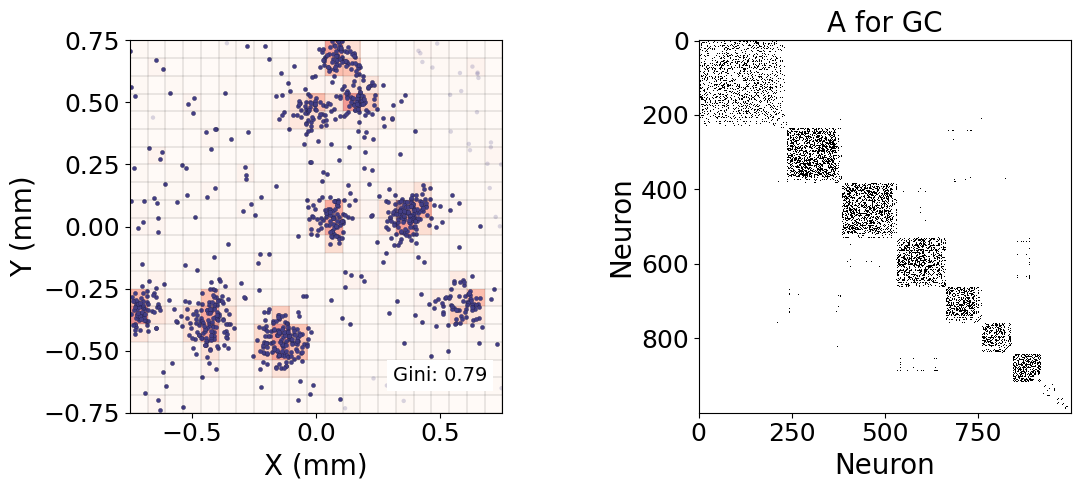

In [69]:
# Poner neuronas en un plano de LxL
## Poner un 70% agragadas y el otro 30% random
## La agregación la hacemos poniendo unos centros de menra aleatoria en la red con una cierta anchura y 
## colocando las neuronas en esos centros, el resto random en el espacio.
# Generar conexiones de acuerdo a la distancia entre neuronas con una cierta probabilidad de conexión.

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from pypalettes import load_cmap

viridis = load_cmap("viridis")


# ============================================================
# Parámetros principales
# ============================================================

L = 1.5              # Tamaño del dominio L x L, en mm
N = 1000          # Número total de neuronas
Neuron_per_center = 80
frac_agg = 0.8 # Fracción de neuronas agregadas
n_centers = N // Neuron_per_center  # Número de centros de agregación
base_sigma = 0.05    # Anchura de los agregados, en mm

r_conn = 0.15   # Radio de conexión, en mm
alpha = 0.5       # Probabilidad de conexión si están dentro del radio

seed = np.random.SeedSequence().entropy
rng = np.random.default_rng(seed)


# ============================================================
# Generar posiciones: 70% agregadas + 30% random
# ============================================================

positions, centers, labels, sigmas = generate_mixed_positions(
    N=N,
    L=L,
    frac_agg=frac_agg,
    n_centers=n_centers,
    base_sigma=base_sigma,
    rng=rng,
    sigma_mode="same",   # "same" o "random"
    sigma_min=0.05,
    sigma_max=0.20
)

# ============================================================
# Crear matriz de adyacencia según distancia y probabilidad alpha
# ============================================================

A = create_distance_network(
    positions=positions,
    r_conn=r_conn,
    alpha=alpha,
    directed=False,
    rng=rng
)

# ============================================================
# Convertir a grafo de NetworkX
# ============================================================
# ============================================================
# Convertir a grafo de NetworkX y quedarse con la componente gigante
# ============================================================

# ============================================================
# Convertir a grafo de NetworkX y detectar componente gigante
# ============================================================

A_full = A.copy()
positions_full = positions.copy()
labels_full = labels.copy()
N_full = N

G_full = nx.from_numpy_array(A_full)

print("Número de neuronas inicial:", N_full)
print("Número de enlaces inicial:", G_full.number_of_edges())
print("Grado medio inicial:", np.mean([d for _, d in G_full.degree()]))
print("Densidad inicial:", nx.density(G_full))

if nx.is_connected(G_full):
    print("La red inicial es conexa")
    GC_nodes = np.arange(N_full)

else:
    GC = max(nx.connected_components(G_full), key=len)
    GC_nodes = np.array(sorted(list(GC)))

    print("La red inicial no es conexa")
    print("Tamaño de la componente gigante:", len(GC_nodes))
    print("Fracción en componente gigante:", len(GC_nodes) / N_full)

# Máscara booleana para saber qué nodos pertenecen a la CG
is_GC = np.zeros(N_full, dtype=bool)
is_GC[GC_nodes] = True

# ============================================================
# Reducir A, positions, labels y N a la componente gigante
# para TODO lo que venga después: Louvain, dinámica, etc.
# ============================================================

A = A_full[np.ix_(GC_nodes, GC_nodes)] # This is the adjacency matrix of the giant component
np.save("A_GC.npy", A)
positions = positions_full[GC_nodes]
np.save("positions_GC.npy", positions)
labels = labels_full[GC_nodes]

N_original = N_full
N = A.shape[0]

G = nx.from_numpy_array(A)

print("\nDespués de quedarnos con la componente gigante:")
print("Número de neuronas:", N)
print("Número de enlaces:", G.number_of_edges())
print("Grado medio:", np.mean([d for _, d in G.degree()]))
print("Densidad:", nx.density(G))
print("¿Es conexa ahora?:", nx.is_connected(G))

# ============================================================
# Ordenar matriz de adyacencia por comunidades
# ============================================================

# Grafo completo, no solo la componente gigante
G_for_plot = nx.from_numpy_array(A_full)

# Detectar comunidades en toda la red
communities_full = nx.community.louvain_communities(G_for_plot, seed=seed)

# Ordenar comunidades por tamaño, de mayor a menor
communities_full = sorted(communities_full, key=len, reverse=True)

# Lista de nodos ordenados por comunidad
ordered_nodes_full = []
community_boundaries_full = []

count = 0
for comm in communities_full:
    comm_sorted = sorted(list(comm))
    ordered_nodes_full.extend(comm_sorted)

    count += len(comm_sorted)
    community_boundaries_full.append(count)

# Reordenar la matriz completa
A_full_ordered = A_full[np.ix_(ordered_nodes_full, ordered_nodes_full)]

print("Número de comunidades detectadas en la red completa:", len(communities_full))
print("Tamaños de comunidades red completa:", [len(c) for c in communities_full])


# ============================================================
# Plot conjunto: posiciones + matriz de adyacencia ordenada
# ============================================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 5),
    gridspec_kw={"width_ratios": [1, 1]}
)

# ============================================================
# Izquierda: distribución espacial
# ============================================================

# ============================================================
# Izquierda: distribución espacial completa
# ============================================================

ax = axes[0]

# Primero ploteamos los nodos que NO están en la CG
ax.scatter(
    positions_full[~is_GC, 0],
    positions_full[~is_GC, 1],
    s=10,
    alpha=0.2,
    color=viridis(0.1),
    label="Out GC",
    edgecolors='none'
)

n_grid = 21
Gini_coeff, H_plot, x_edges, y_edges = Gini(
    X=positions_full[:, 0],
    Y=positions_full[:, 1],
    L=L,
    n_grid=n_grid
)

xmin = -L/2
xmax = L/2
ymin = -L/2
ymax = L/2

x_grid = np.linspace(xmin, xmax, n_grid + 1)
y_grid = np.linspace(ymin, ymax, n_grid + 1)

for x in x_grid:
    ax.axvline(x, color='black', lw=0.3, alpha=0.4)

for y in y_grid:
    ax.axhline(y, color='black', lw=0.3, alpha=0.4)

ax.imshow(
    H_plot,
    extent=[xmin, xmax, ymin, ymax],
    origin='lower',
    cmap='Reds',
    alpha=0.5
)

ax.text(
    0.5, -0.6,
    f"Gini: {Gini_coeff:.2f}",
    fontsize=14,
    color='black',
    ha='center',
    va='center',
    bbox=dict(facecolor='white', alpha=1, edgecolor='none')
)

# SHow a grid using n_grid 

# Después ploteamos encima los nodos de la CG
ax.scatter(
    positions_full[is_GC, 0],
    positions_full[is_GC, 1],
    s=10,
    alpha=1,
    color=viridis(0.1),
    label="GC", 
    edgecolors='black', 
    linewidths=0.1
)

ax.set_xlim(-L/2, L/2)
ax.set_ylim(-L/2, L/2)
ax.set_aspect("equal")

ax.set_xlabel("X (mm)", fontsize=20)
ax.set_ylabel("Y (mm)", fontsize=20)
# Legend makong bigger the dots, alph = 0.8 a to make it more visible, and frameon to make it more clear
# legend = ax.legend(frameon=True, fontsize=18, loc="best", markerscale=3, framealpha = 1.0, edgecolor = "black")
ax.tick_params(labelsize=18)


# ============================================================
# Derecha: matriz de adyacencia ordenada por comunidades
# ============================================================

ax = axes[1]

im = ax.imshow(
    A_full_ordered,
    cmap="Greys",
    interpolation="nearest",
    origin="upper"
)

ax.set_title("A for GC", fontsize=20)
ax.set_xlabel("Neuron", fontsize = 20)
ax.set_ylabel("Neuron", fontsize = 20)
ax.tick_params(labelsize=18)
# ax.set_xticks([0, 1000, 2000])
# ax.set_xticklabels(["0", "1k", "2k"])
# ax.set_yticks([0, 1000, 2000])
# ax.set_yticklabels(["0", "1k", "2k"])

# Dibujar líneas separando comunidades
# for boundary in community_boundaries[:-1]:
#     ax.axhline(boundary - 0.5, color="red", linewidth=0.8, alpha=0.7)
#     ax.axvline(boundary - 0.5, color="red", linewidth=0.8, alpha=0.7)

plt.tight_layout()
plt.show()

In [70]:
 
# Reproducibilidad opcional
np.random.seed(42)

## Simulations
Ne = int(0.8 * N)  # Número de neuronas excitatorias
Ni = N - Ne        # Número de neuronas inhibitorias

SIM_TIME = 10000
MAX_EXC_WEIGHT = 25
MAX_INH_WEIGHT = 0.5

W = np.hstack([
    MAX_EXC_WEIGHT * np.random.rand(N, Ne),
    -MAX_INH_WEIGHT * np.random.rand(N, Ni)
])

S = A * W

# =========================
# Izhikevich parameters
# =========================

re = np.random.rand(Ne)
ri = np.random.rand(Ni)

a = np.concatenate([
    0.02 * np.ones(Ne),
    0.02 + 0.08 * ri
])

b = np.concatenate([
    0.2 * np.ones(Ne),
    0.25 - 0.05 * ri
])

c = np.concatenate([
    -65 + 15 * re**2,
    -65 * np.ones(Ni)
])

d = np.concatenate([
    8 - 6 * re**2,
    2 * np.ones(Ni)
])

# =========================
# MAIN SIMULATION
# =========================

NOISE_MAX = 3

v = -65 * np.ones(N)
u = b * v

firings = []

for t in range(1, SIM_TIME + 1):

    I = np.concatenate([
        NOISE_MAX * np.random.randn(Ne),
        2 * np.random.randn(Ni)
    ])

    fired = np.where(v >= 30)[0]

    if len(fired) > 0:
        firings.extend([(t, neuron) for neuron in fired])

        v[fired] = c[fired]
        u[fired] += d[fired]

        I += np.sum(S[:, fired], axis=1)

    v += 0.5 * (0.04 * v**2 + 5 * v + 140 - u + I)
    v += 0.5 * (0.04 * v**2 + 5 * v + 140 - u + I)
    u += a * (b * v - u)

firings = np.array(firings)

# =========================
# Raster plot
# =========================

# plt.figure(figsize=(10, 5))

# plt.scatter(
#     firings[:, 0],
#     firings[:, 1],
#     s=7,
#     color="black"
# )

# plt.xlabel("Time (ms)")
# plt.ylabel("Neuron")
# plt.title("Raster plot of activity")
# plt.tight_layout()
# plt.show()

c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Threshold para top 10% de |Pearson|: 0.9830
Número de enlaces funcionales binarios: 44096


C:\Users\Admin\AppData\Local\Temp\ipykernel_2488\3024335230.py:323: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


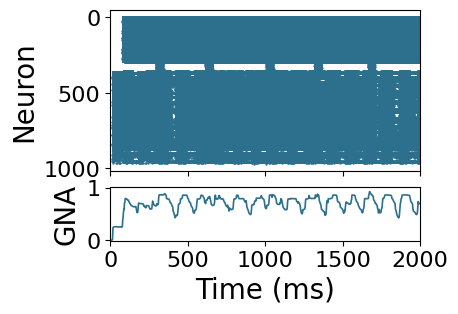

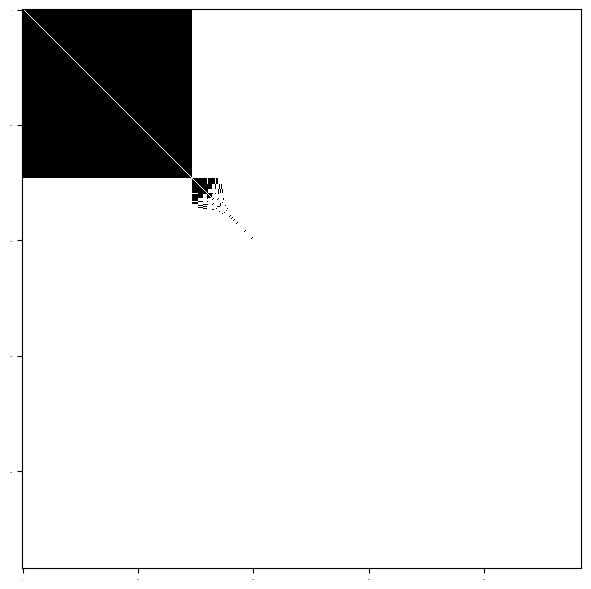

Mean peak height: 0.8103
Std peak height: 0.0824


In [71]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import scipy.signal as signal
from scipy.signal import find_peaks

# ============================================================
# FUNCIONES
# ============================================================

def build_activity_matrix_from_raster(firings, N, SIM_TIME, bin_size=25):
    """
    Construye una matriz M de actividad neuronal.
    
    M[t_bin, neuron] = 1 si la neurona dispara al menos una vez
    en esa ventana temporal.
    """
    
    n_bins = int(np.ceil(SIM_TIME / bin_size))
    M = np.zeros((n_bins, N), dtype=float)
    
    if firings.size == 0:
        return M
    
    times = firings[:, 0].astype(int)
    neurons = firings[:, 1].astype(int)
    
    bin_indices = (times - 1) // bin_size
    
    valid = (bin_indices >= 0) & (bin_indices < n_bins) & (neurons >= 0) & (neurons < N)
    bin_indices = bin_indices[valid]
    neurons = neurons[valid]
    
    M[bin_indices, neurons] = 1.0
    
    return M


def compute_pearson_functional_matrix(M):
    """
    Calcula la matriz funcional usando correlación de Pearson
    entre columnas de M, es decir, entre neuronas.
    """
    
    F = np.corrcoef(M, rowvar=False)
    
    # Quitar NaNs debidos a neuronas sin actividad o varianza cero
    F = np.nan_to_num(F, nan=0.0, posinf=0.0, neginf=0.0)
    
    # Sin autocorrelaciones
    np.fill_diagonal(F, 0.0)
    
    return F


def binarize_top_percent_abs(F, top_percent=10):
    """
    Binariza quedándose con el top_percent % de correlaciones absolutas
    más fuertes de la parte triangular superior.
    """
    
    F_abs = np.abs(F)
    N = F.shape[0]
    
    iu = np.triu_indices(N, k=1)
    values = F_abs[iu]
    
    # Nos quedamos solo con valores positivos para evitar que los ceros dominen
    values_pos = values[values > 0]
    
    if len(values_pos) == 0:
        return np.zeros_like(F, dtype=int), np.nan
    
    threshold = np.percentile(values_pos, 100 - top_percent)
    
    F_binary = (F_abs >= threshold).astype(int)
    np.fill_diagonal(F_binary, 0)
    
    # Simetrizar por seguridad
    F_binary = np.maximum(F_binary, F_binary.T)
    
    return F_binary, threshold


def community_order_from_binary_matrix(F_binary, seed=42):
    """
    Ordena las neuronas según comunidades Louvain.
    Dentro de cada comunidad ordena por grado descendente.
    """
    
    G = nx.from_numpy_array(F_binary)
    
    if G.number_of_edges() == 0:
        return np.arange(F_binary.shape[0])
    
    communities = nx.community.louvain_communities(G, seed=seed)
    
    # Ordenar comunidades por tamaño
    communities = sorted(communities, key=len, reverse=True)
    
    order = []
    
    for comm in communities:
        comm = list(comm)
        degrees = dict(G.degree(comm))
        
        # Ordenar nodos dentro de la comunidad por grado
        comm_sorted = sorted(comm, key=lambda x: degrees[x], reverse=True)
        order.extend(comm_sorted)
    
    # Por seguridad, añadir nodos que no hayan entrado
    missing = [i for i in range(F_binary.shape[0]) if i not in order]
    order.extend(missing)
    
    return np.array(order)


def reorder_raster(firings, order):
    """
    Aplica al raster el mismo orden que a la matriz.
    """
    
    old_to_new = np.empty_like(order)
    old_to_new[order] = np.arange(len(order))
    
    firings_ordered = firings.copy()
    firings_ordered[:, 1] = old_to_new[firings[:, 1].astype(int)]
    
    return firings_ordered

def compute_GNA_from_raster(firings_t, firings_i, N, SIM_TIME, W=25):
    
    firings_t = np.asarray(firings_t, dtype=int)
    firings_i = np.asarray(firings_i, dtype=int) - 1  # 0-based
    
    # Para cada neurona, guardamos el último tiempo en que disparó
    last_spike = -np.inf * np.ones(N)
    
    GNA = np.zeros(SIM_TIME)
    active_count = 0
    
    # Ordenar por tiempo (importante)
    order = np.argsort(firings_t)
    firings_t = firings_t[order]
    firings_i = firings_i[order]
    
    idx = 0
    
    for t in range(1, SIM_TIME + 1):
        
        # Añadir spikes en este tiempo
        while idx < len(firings_t) and firings_t[idx] == t:
            neuron = firings_i[idx]
            
            # Si estaba inactiva, ahora cuenta
            if last_spike[neuron] < t - W:
                active_count += 1
            
            last_spike[neuron] = t
            idx += 1
        
        # Quitar neuronas que han dejado de estar activas
        active_count = np.sum(last_spike >= t - W)
        
        GNA[t-1] = active_count / N
    
    return GNA

def find_GNA_peaks(GNA):

    prom = 0.2 * np.std(GNA)

    peaks, properties = find_peaks(
        GNA,
        prominence=prom,  # prominencia mínima del pico
        height = 0.05,
        distance=20
    )

    peak_heights = properties.get("peak_heights", GNA[peaks] if len(peaks) > 0 else np.array([]))

    if len(peak_heights) == 0:
        mean_peak_height = 0.0
        std_peak_height = 0.0
    else:
        mean_peak_height = peak_heights.mean()
        std_peak_height = peak_heights.std()
    
    return peaks, peak_heights, mean_peak_height, std_peak_height


# ============================================================
# PARÁMETROS
# ============================================================

bin_size = 25          # ms
top_percent = 10      # top 10% de correlaciones absolutas

# ============================================================
# MATRIZ FUNCIONAL
# ============================================================

M = build_activity_matrix_from_raster(
    firings=firings,
    N=N,
    SIM_TIME=SIM_TIME,
    bin_size=bin_size
)

F = compute_pearson_functional_matrix(M)

F_binary, threshold = binarize_top_percent_abs(
    F,   
    top_percent = top_percent
)

print(f"Threshold para top {top_percent}% de |Pearson|: {threshold:.4f}")
print(f"Número de enlaces funcionales binarios: {F_binary.sum() // 2}")

# ============================================================
# ORDEN POR COMUNIDADES
# ============================================================

order = community_order_from_binary_matrix(F_binary, seed=42)

F_ordered = F[np.ix_(order, order)]
F_binary_ordered = F_binary[np.ix_(order, order)]

firings_ordered = reorder_raster(firings, order)

# ============================================================
# PLOTS NUEVOS
# Raster + GNA debajo compartiendo eje x
# Matriz funcional en figura aparte
# ============================================================

# ------------------------------------------------------------
# Calcular GNA y picos
# OJO: tu función compute_GNA_from_raster resta 1 a firings_i.
# Como firings[:, 1] ya suele estar en 0-based, le paso +1 para compensarlo.
# ------------------------------------------------------------

GNA = compute_GNA_from_raster(
    firings_t=firings[:, 0],
    firings_i=firings[:, 1] + 1,
    N=N,
    SIM_TIME=SIM_TIME,
    W=25
)

peaks, peak_heights, mean_peak_height, std_peak_height = find_GNA_peaks(GNA)

# ============================================================
# FIGURA 1: Raster arriba + GNA debajo
# ============================================================

fig, axes = plt.subplots(
    2, 1,
    figsize=(4,3),
    sharex=True,
    gridspec_kw={
        "height_ratios": [3, 1],
        "hspace": 0.15
    }
)

ax_raster = axes[0]
ax_gna = axes[1]

# ------------------------------------------------------------
# Raster ordenado
# ------------------------------------------------------------

ax_raster.scatter(
    firings_ordered[:, 0],
    firings_ordered[:, 1],
    s=0.5,
    color=viridis(0.3)
)

ax_raster.set_ylabel("Neuron", fontsize=20)
ax_raster.tick_params(axis="both", labelsize=16)

# Para que la neurona 0 quede arriba
ax_raster.invert_yaxis()

# Quitar etiquetas del eje x en el raster
ax_raster.tick_params(labelbottom=False)
ax_raster.set_xlim(0, 2000)

# ------------------------------------------------------------
# GNA debajo
# ------------------------------------------------------------

time_axis = np.arange(1, SIM_TIME + 1)

ax_gna.plot(
    time_axis,
    GNA,
    color=viridis(0.3),
    linewidth=1.2, 
)

# ax_gna.scatter(
#     peaks + 1,
#     GNA[peaks],
#     color=viridis(0.8),
#     s=12,
#     zorder=5,
#     label="Peaks"
# )

ax_gna.set_xlabel("Time (ms)", fontsize=20)
ax_gna.set_ylabel("GNA", fontsize=20)
ax_gna.tick_params(axis="both", labelsize=16)

ax_gna.set_ylim(-0.01, 1.01)
ax_gna.set_xlim(0, 2000)

# Si quieres enseñar solo los primeros 5000 ms, activa esto:
# ax_gna.set_xlim(0, 5000)

plt.tight_layout()
plt.show()


# ============================================================
# FIGURA 2: Matriz funcional en plot aparte
# ============================================================

fig, ax = plt.subplots(figsize=(6, 6))

im = ax.imshow(
    F_binary_ordered,
    cmap="Greys",
    origin="upper",
    interpolation="nearest"
)

# ax.set_xlabel("Neuron ordered by communities", fontsize=16)
# ax.set_ylabel("Neuron ordered by communities", fontsize=16)
ax.tick_params(labelsize=0)


# Si no quieres ticks porque hay muchas neuronas:
# ax.set_xticks([])
# ax.set_yticks([])

plt.tight_layout()
plt.show()


# ============================================================
# Imprimir resumen
# ============================================================

print(f"Mean peak height: {mean_peak_height:.4f}")
print(f"Std peak height: {std_peak_height:.4f}")